Shapes (targets, predictions): (899, 32) (899, 32)


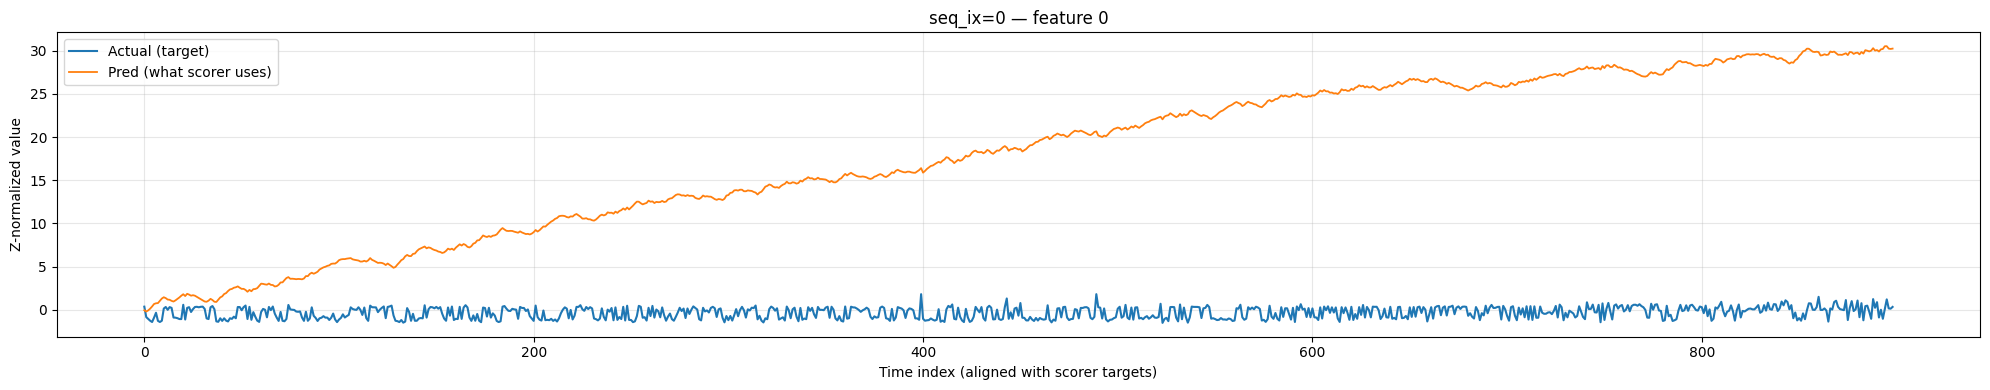

In [5]:
import os, sys, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from solution import PredictionModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CURRENT_DIR = os.getcwd()

from utils import ScorerStepByStep, DataPoint

# ---- pick one sequence + one feature ---- #
seq_ix_to_plot = 0      # <--- change this to the seq you want
feature_to_plot = 0   # <--- 0–31

# ---- load dataset ---- #
scorer = ScorerStepByStep(f"{CURRENT_DIR}/../../datasets/train.parquet")
df = scorer.dataset

# keep **only** this sequence, and sort properly
df_seq = (
    df[df["seq_ix"] == seq_ix_to_plot]
    .sort_values("step_in_seq")
    .reset_index(drop=True)
)

# ---- instantiate model exactly as in solution.py ---- #
model = PredictionModel(delta_scale=0.30)
model.eval()

pred_list = []
true_list = []
next_prediction = None

# this is the scorer loop, but only for this one seq
for row in df_seq.values:
    seq_ix = int(row[0])          # constant = seq_ix_to_plot
    step_in_seq = int(row[1])
    need_prediction = bool(row[2])
    new_state = row[3:].astype(np.float32)

    # scorer uses new_state as target for the *previous* prediction
    if next_prediction is not None:
        pred_list.append(next_prediction)
        true_list.append(new_state)

    dp = DataPoint(
        seq_ix=seq_ix,
        step_in_seq=step_in_seq,
        need_prediction=need_prediction,
        state=new_state,
    )

    next_prediction = model.predict(dp)

pred = np.array(pred_list)   # what scorer uses as predictions
true = np.array(true_list)   # what scorer uses as targets

print("Shapes (targets, predictions):", true.shape, pred.shape)

# ---- plot ---- #
plt.figure(figsize=(20, 4))
plt.plot(true[:, feature_to_plot], label="Actual (target)", linewidth=1.5)
plt.plot(pred[:, feature_to_plot], label="Pred (what scorer uses)", linewidth=1.3)
plt.title(f"seq_ix={seq_ix_to_plot} — feature {feature_to_plot}")
plt.xlabel("Time index (aligned with scorer targets)")
plt.ylabel("Z-normalized value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
